<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Pie Charts**


Estimated time needed: **30** minutes


- In this lab, you will focus on visualizing data.

- The provided dataset will be loaded into pandas for analysis.

- Various pie charts will be created to:
   - Analyze developer preferences.
  
   - Identify technology usage trends.
    
- The lab aims to provide insights into key variables using visual representations.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition of data.

-   Visualize comparison of data.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [16]:
!pip install pandas

In [17]:
!pip install matplotlib

In [18]:
!pip install seaborn

In [19]:
!pip install numpy

**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



In [33]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-07-10 08:44:20--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
169.63.118.104ourses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  37.9MB/s    in 4.1s    

2026-07-10 08:44:24 (37.0 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Composition with Pie Charts


##### 1.1 Create a Pie Chart of the Top 5 Databases Respondents Want to Work With


In the survey data, the `DatabaseWantToWorkWith` column lists the databases that respondents wish to work with. Let’s visualize the top 5 most-desired databases in a pie chart.



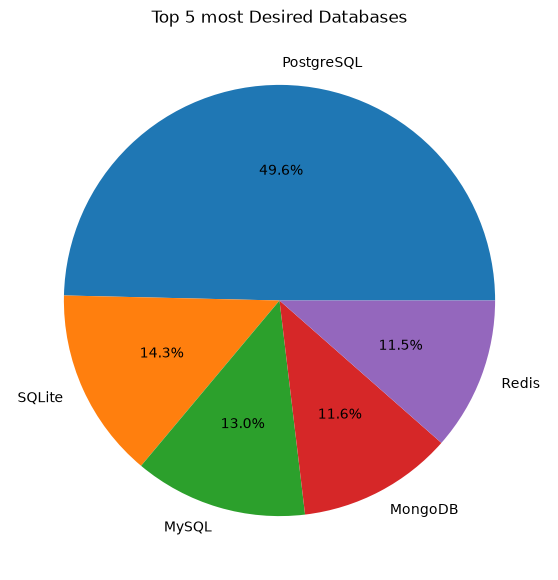

In [34]:
##Write your code here
# midpoint = {
#     'Under 18 years old': 15,
#     '18-24 years old': 21,
#     '25-34 years old':29.5,
#     '35-44 years old':39.5,
#     '45-54 years old':49.5,
#     '55-64 years old':59.5,
#     '65 years or older':70,
#     'Prefer not to say':np.nan
# }
# df['Age'] = df['Age'].map(midpoint)

# numeric_cols = df.select_dtypes(include=['number']).columns
# categorical_cols = df.select_dtypes(include=['str', 'category']).columns


# fill_values = {}
# for col in numeric_cols:
#     fill_values[col] = df[col].median()

# for col in categorical_cols:
#     # Check if mode exists to prevent indexing errors on empty columns
#     if not df[col].mode().empty:
#         fill_values[col] = df[col].mode()[0]

# df = df.fillna(value=fill_values)


df_db = df.copy()
df_db["DatabaseWantToWorkWith"] = df_db["DatabaseWantToWorkWith"].str.split(";")
df_db = df_db.explode("DatabaseWantToWorkWith")

top5db = df_db["DatabaseWantToWorkWith"].value_counts().head().index

df_top5db_final = df_db[df_db["DatabaseWantToWorkWith"].isin(top5db)]
db_counts = df_top5db_final["DatabaseWantToWorkWith"].value_counts()

plt.figure(figsize=(7,7))
db_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Top 5 most Desired Databases")
plt.show()

The `DevType` column lists the developer types for respondents. We’ll examine the distribution by showing the top 5 developer roles in a pie chart.



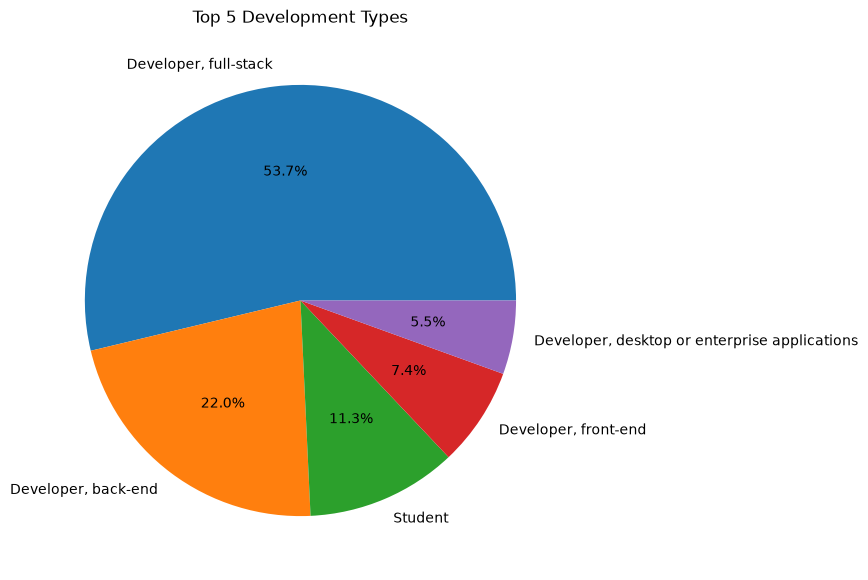

In [35]:
##Write your code here
df_dev = df.copy()
df_dev['DevType'] = df_dev['DevType'].str.split(';')
df_dev = df_dev.explode('DevType')
top5dev = df_dev["DevType"].value_counts().head().index

df_dev_final = df_dev[df_dev["DevType"].isin(top5dev)]
df_devplot = df_dev_final['DevType'].value_counts()

plt.figure(figsize=(7,7))
df_devplot.plot(kind='pie', autopct='%1.1f%%')
plt.title("Top 5 Development Types")
plt.show()

##### 1.3 Create a pie chart for the operating systems used by respondents for professional use


The `OpSysProfessional use` use column shows the operating systems developers use professionally. Let’s visualize the distribution of the top operating systems in a pie chart.



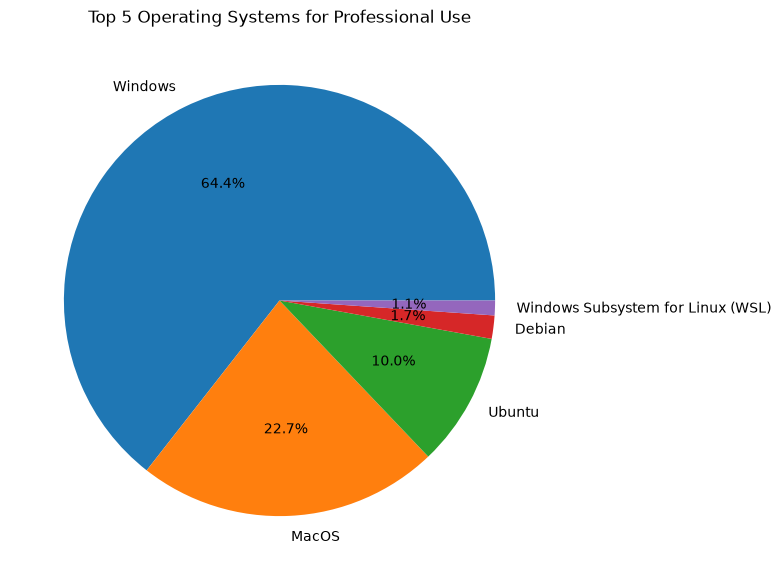

In [39]:
##Write your code here
df['OpSysProfessional use'].unique()
df_op = df.copy()
df_op['OpSysProfessional use'] = df['OpSysProfessional use'].str.split(';')
df_op = df_op.explode('OpSysProfessional use')
top5op = df_op["OpSysProfessional use"].value_counts().head().index

df_op_final = df_dev[df_dev["OpSysProfessional use"].isin(top5op)]
df_opplot = df_op_final['OpSysProfessional use'].value_counts()

plt.figure(figsize=(7,7))
df_opplot.plot(kind='pie', autopct='%1.1f%%')
plt.title("Top 5 Operating Systems for Professional Use")
plt.show()

### Task 2: Additional Visualizations and Comparisons


##### 2.1 Pie Chart for Top 5 Programming Languages Respondents Have Worked With


The `LanguageHaveWorkedWith` column contains the programming languages that respondents have experience with. We’ll plot a pie chart to display the composition of the top 5 languages.



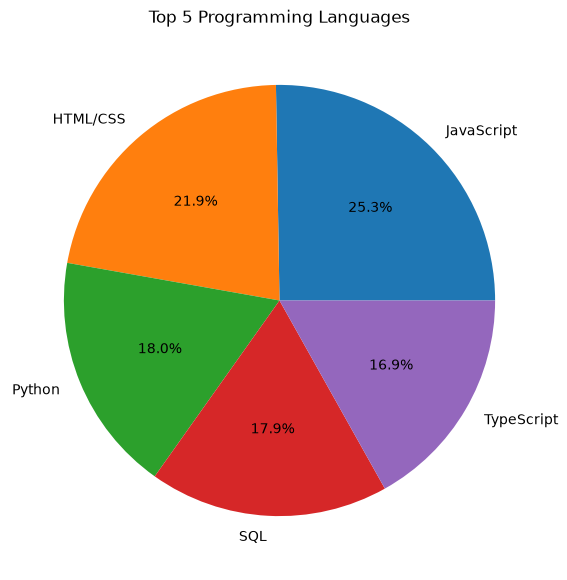

In [40]:
##Write your code here
df_lan = df.copy()
df_lan['LanguageHaveWorkedWith'] = df_lan['LanguageHaveWorkedWith'].str.split(';')
df_lan = df_lan.explode('LanguageHaveWorkedWith')

top5lan = df_lan['LanguageHaveWorkedWith'].value_counts().head().index
df_toplan = df_lan[df_lan['LanguageHaveWorkedWith'].isin(top5lan)]
df_lanplot = df_toplan['LanguageHaveWorkedWith'].value_counts()

plt.figure(figsize=(7,7))
df_lanplot.plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 5 Programming Languages')
plt.show()


##### 2.2 Pie Chart for Top Collaboration Tools used in Professional Use


Using the `NEWCollabToolsHaveWorkedWith` column, we’ll identify and visualize the top collaboration tools respondents use in their professional work.



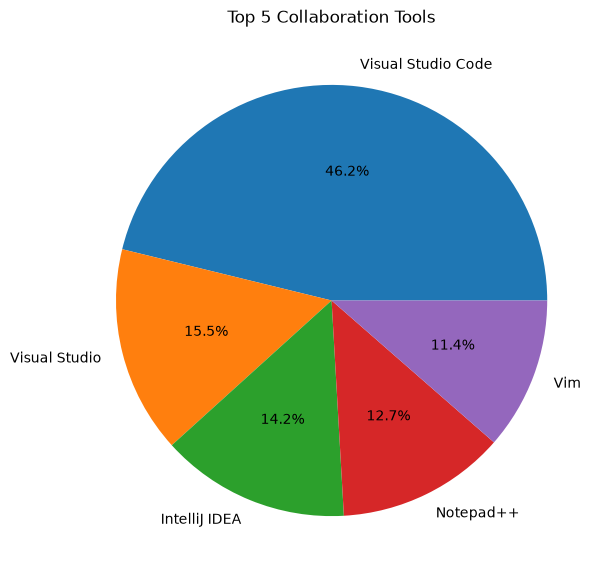

In [41]:
##Write your code here
df_nc = df.copy()
df_nc['NEWCollabToolsHaveWorkedWith'] = df_nc['NEWCollabToolsHaveWorkedWith'].str.split(';')
df_nc = df_nc.explode('NEWCollabToolsHaveWorkedWith')

top5nc = df_nc['NEWCollabToolsHaveWorkedWith'].value_counts().head().index
df_topnc = df_nc[df_nc['NEWCollabToolsHaveWorkedWith'].isin(top5nc)]
df_ncplot = df_topnc['NEWCollabToolsHaveWorkedWith'].value_counts()

plt.figure(figsize=(7,7))
df_ncplot.plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 5 Collaboration Tools')
plt.show()


### Task 3: Analyzing and Interpreting Composition


In this task, you will create additional pie charts to analyze specific aspects of the survey data. Use `pandas` and `matplotlib` to complete each task and interpret the findings.



##### 3.1 Pie Chart of `Respondents` Most Admired Programming Languages


The `LanguageAdmired` column lists the programming languages respondents admire most. Create a pie chart to visualize the top 5 admired languages.



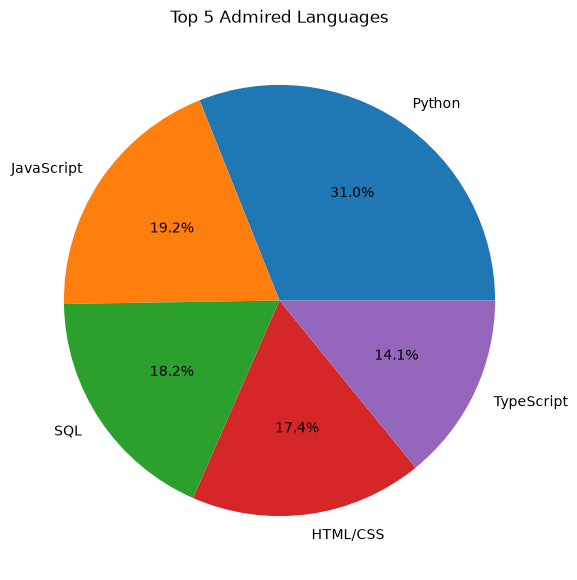

In [45]:
##Write your code here
df_al = df.copy()
df_al['LanguageAdmired'] = df_al['LanguageAdmired'].str.split(';')
df_al = df_al.explode('LanguageAdmired')

top5al = df_al['LanguageAdmired'].value_counts().head().index
df_topal = df_al[df_al['LanguageAdmired'].isin(top5al)]
df_alplot = df_topal['LanguageAdmired'].value_counts()

plt.figure(figsize=(7,7))
df_alplot.plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 5 Admired Languages')
plt.show()

#From the below ouptput, the top five most admired languages in order are Python, JavaScript, SQL, HTML/CSS and TypeScript

##### 3.2 Pie Chart of Tools Used for AI Development


Using the `AIToolCurrently Using` Using column, create a pie chart to visualize the top 5 tools developers are currently using for AI development.



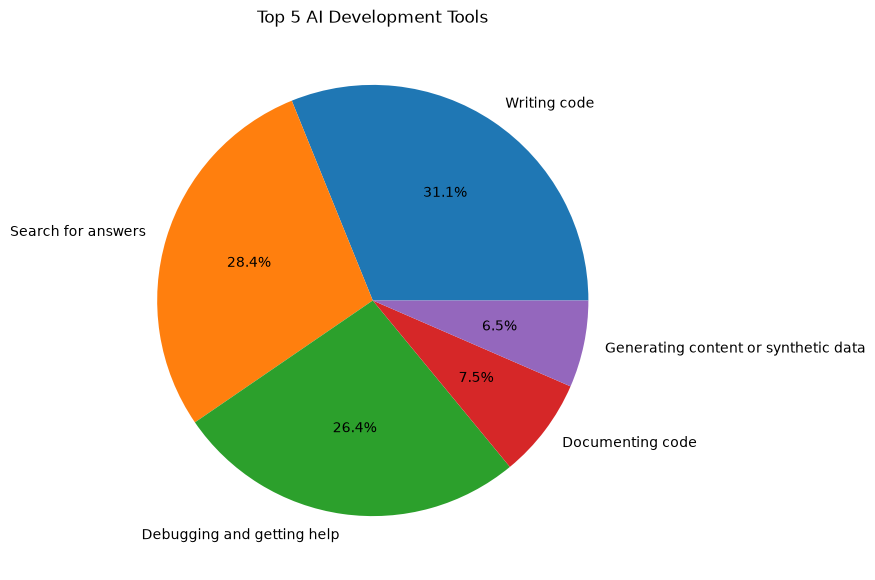

In [51]:
##Write your code here
df_ai = df.copy()
df_ai['AIToolCurrently Using'] = df_ai['AIToolCurrently Using'].str.split(';')
df_ai = df_ai.explode('AIToolCurrently Using')

top5ai = df_ai['AIToolCurrently Using'].value_counts().head().index
df_topai = df_ai[df_ai['AIToolCurrently Using'].isin(top5ai)]
df_aiplot = df_topai['AIToolCurrently Using'].value_counts()

plt.figure(figsize=(7,7))
df_aiplot.plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 5 AI Development Tools')
plt.show()

#From the below ouptput, the top five most used tools for AI dev in order are Writing code, Search for answers, Debugging and getting help, Documenting code and Generating content or synthetic data

##### 3.3 Pie Chart for Preferred Web Frameworks


The `WebframeWantToWorkWith` column includes web frameworks that respondents are interested in working with. Visualize the top 5 frameworks in a pie chart.



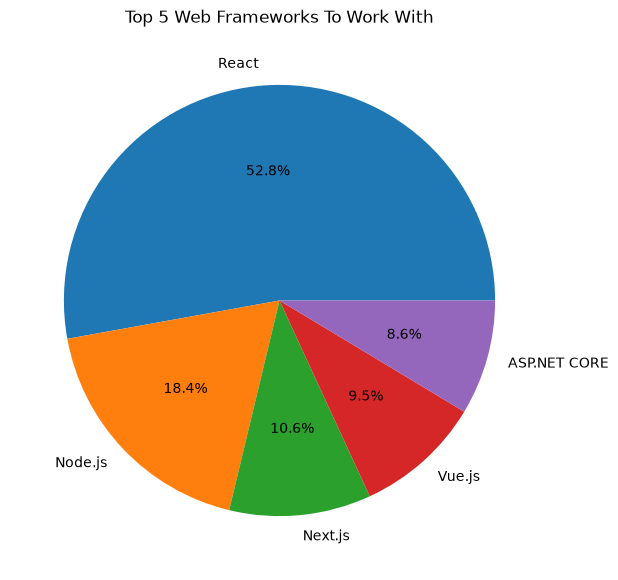

In [53]:
##Write your code here
df_wf = df.copy()
df_wf['WebframeWantToWorkWith'] = df_wf['WebframeWantToWorkWith'].str.split(';')
df_wf = df_wf.explode('WebframeWantToWorkWith')

top5wf = df_wf['WebframeWantToWorkWith'].value_counts().head().index
df_topwf = df_wf[df_wf['WebframeWantToWorkWith'].isin(top5wf)]
df_wfplot = df_topwf['WebframeWantToWorkWith'].value_counts()

plt.figure(figsize=(7,7))
df_wfplot.plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 5 Web Frameworks To Work With')
plt.show()

#From the below ouptput, the top five most used web frameworks in order are React, Node.js, Next.js, Vue.js and ASP.NET CORE

##### 3.4 Pie Chart for Most Desired Embedded Technologies


Using the `EmbeddedWantToWorkWith` column, create a pie chart to show the top 5 most desired embedded technologies that respondents wish to work with.



In [54]:
##Write your code here
df_et = df.copy()
df_et['EmbeddedWantToWorkWith'] = df_et['EmbeddedWantToWorkWith'].str.split(';')
df_et = df_et.explode('EmbeddedWantToWorkWith')

top5e = df_wf['EmbeddedWantToWorkWith'].value_counts().head().index
df_topwf = df_wf[df_wf['EmbeddedWantToWorkWith'].isin(top5wf)]
df_wfplot = df_topwf['EmbeddedWantToWorkWith'].value_counts()

plt.figure(figsize=(7,7))
df_wfplot.plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 5 Embedded Technologies To Work With')
plt.show()

#From the below ouptput, the top five most used web frameworks in order are React, Node.js, Next.js, Vue.js and ASP.NET CORE

<StringArray>
[                                                                                                                                       'Rasberry Pi',
                                                                                                                                  'CMake;Rasberry Pi',
                                                                                                                                'Arduino;Rasberry Pi',
                                                                                                                          'Arduino;CMake;Rasberry Pi',
                                                                                                                                               'MSVC',
                                                                                                                         'CMake;GNU GCC;LLVM's Clang',
                                                                                

### Summary


After completing this lab, you will be able to:
- Create pie charts to visualize developer preferences across databases, programming languages, AI tools, and cloud platforms.
- Identify trends in technology usage, role distribution, and tool adoption through pie charts.
- Analyze and compare data composition across various categories to gain insights into developer preferences.




## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
